# ex08_lti_wts_bootstrap

Interactive notebook version of the Python example.
Edit parameters and rerun cells to explore the model behavior.


## MATLAB-style Sections

- LTI model of a Coleman transformed wind turbine system
- Closed-loop identification experiment
- Uncertainty bounds using Bootstrap simulations


## Imports


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from _common import (
    estimate_varx_abcdk,
    frequency_response,
    simulate_lti,
    stable_random_system,
    state_space_model,
    vaf_percent,
)
from pbsid.plotting import dbodemagpatch, plot_pole_map

## LTI Model Of A Coleman Transformed Wind Turbine System
Generate a stable surrogate LTI wind turbine model for the bootstrap notebook port.

In [2]:
a, b, c, d, k = stable_random_system(n=7, r=2, l_out=3, seed=108)

## Closed-Loop Identification Experiment
Run the surrogate closed-loop bootstrap identification workflow.

In [3]:
n_samples = 5000
bootstrap_runs = 20
h = 0.1
rng = np.random.default_rng(108)
u = np.column_stack(
    (np.sign(rng.standard_normal(n_samples)), 1e3 * np.sign(rng.standard_normal(n_samples)))
).astype(np.float64)
w = np.logspace(-2, np.log10(np.pi / h), 1000)
reference_response = np.abs(frequency_response(state_space_model(a, b, c, d, h), w))
y, _ = simulate_lti(a, b, c, d, u, k=k, e=0.03 * rng.standard_normal((n_samples, 3)))
y_nom, _ = simulate_lti(a, b, c, d, u)
_, ai0, bi0, ci0, di0, _, _, _ = estimate_varx_abcdk(u, y, n=a.shape[0], f=20, p=50)
y_hat0, _ = simulate_lti(ai0, bi0, ci0, di0, u)
resid0 = y - y_hat0
vaf_reference = vaf_percent(y_nom, y_hat0)
vaf_runs = np.zeros((bootstrap_runs, y.shape[1]), dtype=np.float64)
pole_store = np.zeros((bootstrap_runs, a.shape[0]), dtype=np.complex128)
response_reference = None
response_min = None
response_max = None
for i in range(bootstrap_runs):
    idx = rng.integers(0, n_samples, size=n_samples)
    y_boot = y_hat0 + resid0[idx, :]
    _, ai, bi, ci, di, _, _, _ = estimate_varx_abcdk(u, y_boot, n=a.shape[0], f=20, p=50)
    y_hat, _ = simulate_lti(ai, bi, ci, di, u)
    response = np.abs(frequency_response(state_space_model(ai, bi, ci, di, h), w))
    vaf_runs[i, :] = vaf_percent(y_nom, y_hat)
    pole_store[i, :] = np.linalg.eigvals(ai)
    if response_min is None:
        response_reference = response.copy()
        response_min = response.copy()
        response_max = response.copy()
    else:
        response_min = np.minimum(response_min, response)
        response_max = np.maximum(response_max, response)

c:\Users\Atindriyo\anaconda3\envs\pbsid-py\Lib\site-packages\control\lti.py:138: UserWarning: __call__: evaluation above Nyquist frequency
  warn("__call__: evaluation above Nyquist frequency")


## Identification Results
Summarize the reference and bootstrap VAF statistics.

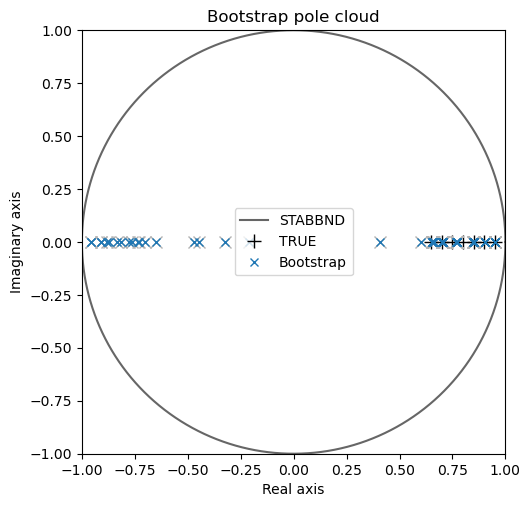

In [4]:
plot_pole_map(
    np.linalg.eigvals(a),
    [("Bootstrap", pole_store, "x", "tab:blue")],
    "Bootstrap pole cloud",
)

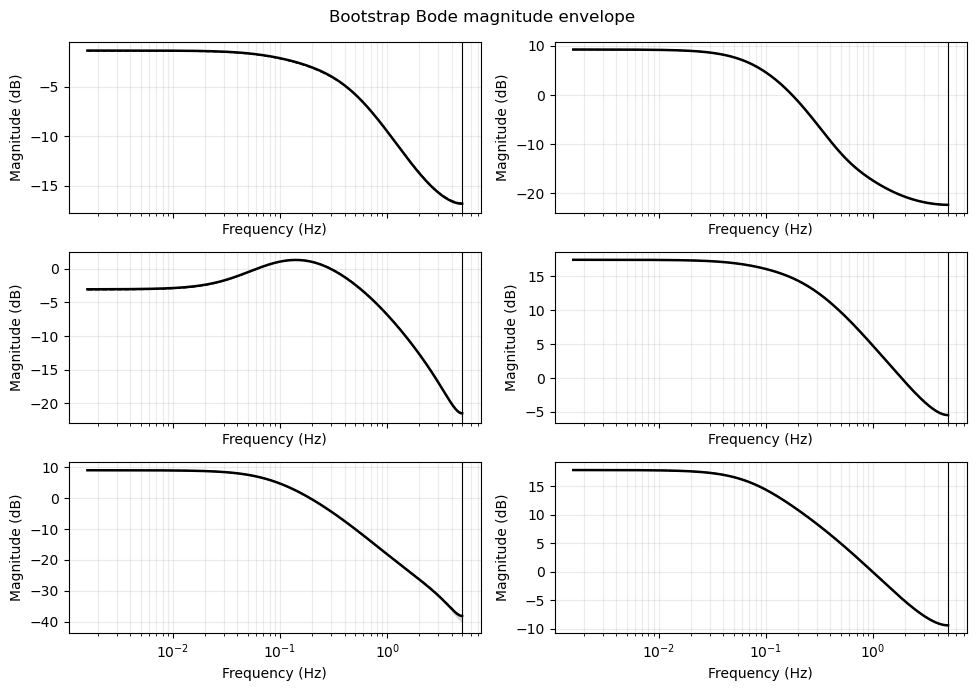

In [7]:
dbodemagpatch(response_reference, response_min, response_max, w, h, reference_response)
fig = plt.gcf()
fig.set_size_inches(10, 7)
fig.suptitle("Bootstrap Bode magnitude envelope")
fig.tight_layout()

In [6]:
print("[ex08-bootstrap]")
print(f"Reference VAF (%): {np.array2string(vaf_reference, precision=2)}")
print(f"Bootstrap mean VAF (%): {np.array2string(np.mean(vaf_runs, axis=0), precision=2)}")
print(f"Bootstrap std VAF  (%): {np.array2string(np.std(vaf_runs, axis=0), precision=2)}")
print(
    f"Mean pole magnitudes: {np.array2string(np.mean(np.abs(pole_store), axis=0), precision=4)}"
 )

[ex08-bootstrap]
Reference VAF (%): [100. 100. 100.]
Bootstrap mean VAF (%): [100. 100. 100.]
Bootstrap std VAF  (%): [1.14e-09 1.23e-10 1.28e-10]
Mean pole magnitudes: [0.7596 0.6841 0.7292 0.7797 0.909  0.8355 0.8337]
